some basic EDA

In [6]:
"""
=============================================================================
EDA — Structural Integrity Monitoring (Case Study 1)
ADB Safegate Hackathon — Vibration-Based Fault Classification
=============================================================================
Dataset: Sensor board vibration data (3-axis, 27 kHz, 8192 samples per capture)
Conditions: Run A (30NM healthy), Run B (Loose), Run C (Mix-45 Deg)
"""

import os, csv, warnings
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

warnings.filterwarnings("ignore")

BASE = "../GDG-Hackaton/Structural.integrity.Seonsor.Board.data/Sensor Board Update Initial Test"
OUT = "../GDG-Hackaton/eda_plots"
os.makedirs(OUT, exist_ok=True)

FS = 27000  # Sampling rate in Hz
N_SAMPLES = 8192
DURATION_S = N_SAMPLES / FS  # ~0.303 s

# Color scheme
COLORS = {"A": "#2196F3", "B": "#F44336", "C": "#FF9800"}
LABELS = {"A": "30NM (Healthy)", "B": "Loose", "C": "Mix-45°"}

# Universal boards (present in all 3 runs for most tests)
UNIVERSAL_BOARDS = ["2523610003", "2523610075", "2523610134", "2524610074", "2524610082", "2546610759", "2548610286"]


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

In [7]:
def load_signal(run, test_id, board):
    """Load a single vibration recording (8192 x 3 axes)."""
    path = f"{BASE}/{run}/{test_id}/{board}"
    if not os.path.isdir(path):
        return None
    files = [f for f in os.listdir(path) if f.endswith(".csv") and not f.endswith("_i.csv")]
    if not files:
        return None
    fpath = os.path.join(path, sorted(files)[0])
    data = np.genfromtxt(fpath, delimiter=",", skip_header=1, usecols=(1, 2, 3))
    if data.shape[0] != N_SAMPLES:
        return None
    return data

def load_metadata():
    """Load Test.csv metadata and clean bolt status."""
    with open(f"{BASE}/Test.csv") as f:
        rows = list(csv.DictReader(f))
    for r in rows:
        r["Bolt Status"] = r["Bolt Status"].replace("Mix- 45 Deg", "Mix-45 Deg")
    return rows

def compute_fft(signal_1d):
    """Compute single-sided FFT magnitude and corresponding frequencies."""
    s = signal_1d - signal_1d.mean()
    fft_mag = np.abs(np.fft.rfft(s))
    freqs = np.fft.rfftfreq(len(s), 1 / FS)
    return freqs, fft_mag

def compute_features(signal_3axis):
    """Compute physics-based features from a 3-axis vibration signal."""
    feats = {}
    for ax_idx, ax_name in enumerate(["X", "Y", "Z"]):
        s = signal_3axis[:, ax_idx]
        s_centered = s - s.mean()
        freqs, fft_mag = compute_fft(s)

        # Time-domain features
        feats[f"{ax_name}_rms"] = np.sqrt(np.mean(s_centered ** 2))
        feats[f"{ax_name}_std"] = np.std(s)
        feats[f"{ax_name}_kurtosis"] = np.mean(s_centered ** 4) / (np.mean(s_centered ** 2) ** 2 + 1e-10)
        feats[f"{ax_name}_crest"] = np.max(np.abs(s_centered)) / (feats[f"{ax_name}_rms"] + 1e-10)
        feats[f"{ax_name}_mean"] = s.mean()

        # Frequency-domain features
        mask = (freqs >= 50) & (freqs <= 4000)
        fft_band = fft_mag[mask]
        freqs_band = freqs[mask]
        feats[f"{ax_name}_spectral_centroid"] = np.sum(freqs_band * fft_band) / (np.sum(fft_band) + 1e-10)
        feats[f"{ax_name}_peak_freq"] = freqs_band[np.argmax(fft_band)] if len(fft_band) > 0 else 0

        # Band energy ratios
        low = np.sum(fft_mag[(freqs >= 50) & (freqs < 200)] ** 2)
        mid = np.sum(fft_mag[(freqs >= 200) & (freqs < 1000)] ** 2)
        high = np.sum(fft_mag[(freqs >= 1000) & (freqs < 4000)] ** 2)
        total = low + mid + high + 1e-10
        feats[f"{ax_name}_energy_low"] = low / total
        feats[f"{ax_name}_energy_mid"] = mid / total
        feats[f"{ax_name}_energy_high"] = high / total
        feats[f"{ax_name}_total_energy"] = total

    return feats

meta = load_metadata()

Plot 1: Time-domain signals...


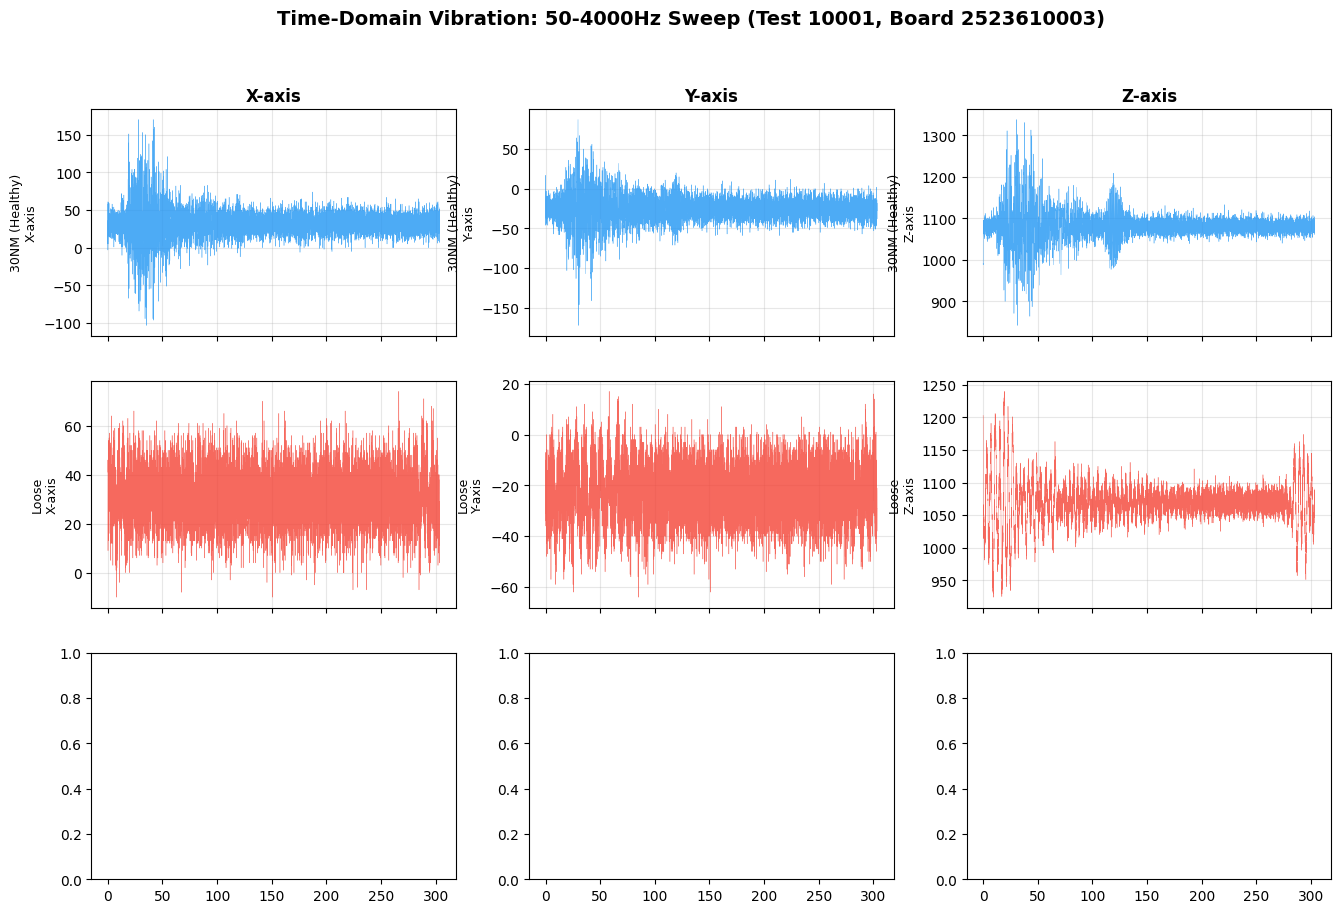

In [13]:
# =============================================================================
# PLOT 1: Time-domain signal comparison across conditions
# =============================================================================
print("Plot 1: Time-domain signals...")
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
board = "2523610003"
time_ms = np.arange(N_SAMPLES) / FS * 1000

for col, ax_name in enumerate(["X", "Y", "Z"]):
    for row, run in enumerate(["A", "B", "C"]):
        sig = load_signal(run, "10001", board)
        if sig is not None:
            ax = axes[row, col]
            ax.plot(time_ms, sig[:, col], color=COLORS[run], linewidth=0.3, alpha=0.8)
            ax.set_ylabel(f"{LABELS[run]}\n{ax_name}-axis", fontsize=9)
            if row == 0:
                ax.set_title(f"{ax_name}-axis", fontsize=12, fontweight="bold")
            if row == 2:
                ax.set_xlabel("Time (ms)")
            ax.grid(True, alpha=0.3)

fig.suptitle("Time-Domain Vibration: 50-4000Hz Sweep (Test 10001, Board 2523610003)", fontsize=14, fontweight="bold")
plt.show()
plt.tight_layout()
plt.savefig(f"{OUT}/01_time_domain_comparison.png", dpi=150, bbox_inches="tight")
plt.close()


Plot 2: FFT comparison...


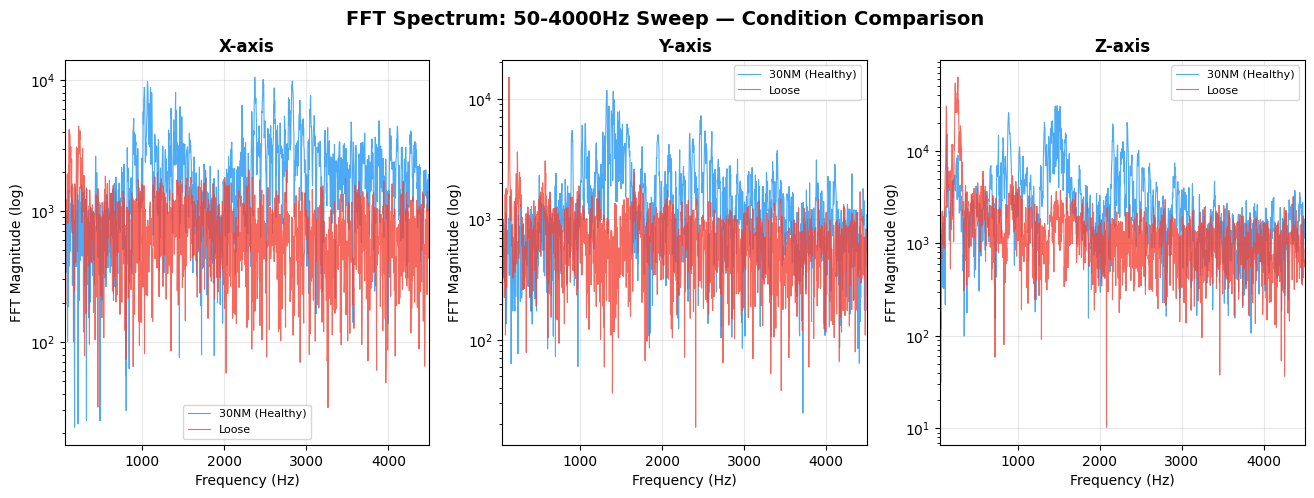

In [14]:
# =============================================================================
# PLOT 2: FFT comparison across conditions
# =============================================================================
print("Plot 2: FFT comparison...")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_idx, ax_name in enumerate(["X", "Y", "Z"]):
    ax = axes[ax_idx]
    for run in ["A", "B", "C"]:
        sig = load_signal(run, "10001", board)
        if sig is not None:
            freqs, fft_mag = compute_fft(sig[:, ax_idx])
            mask = (freqs >= 50) & (freqs <= 4500)
            ax.semilogy(freqs[mask], fft_mag[mask], color=COLORS[run], label=LABELS[run], linewidth=0.8, alpha=0.8)
    ax.set_title(f"{ax_name}-axis", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("FFT Magnitude (log)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(50, 4500)

fig.suptitle("FFT Spectrum: 50-4000Hz Sweep — Condition Comparison", fontsize=14, fontweight="bold")
plt.show()
plt.tight_layout()
plt.savefig(f"{OUT}/02_fft_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

Plot 3: Feature distributions...
  Collected: A=35, B=35, C=28


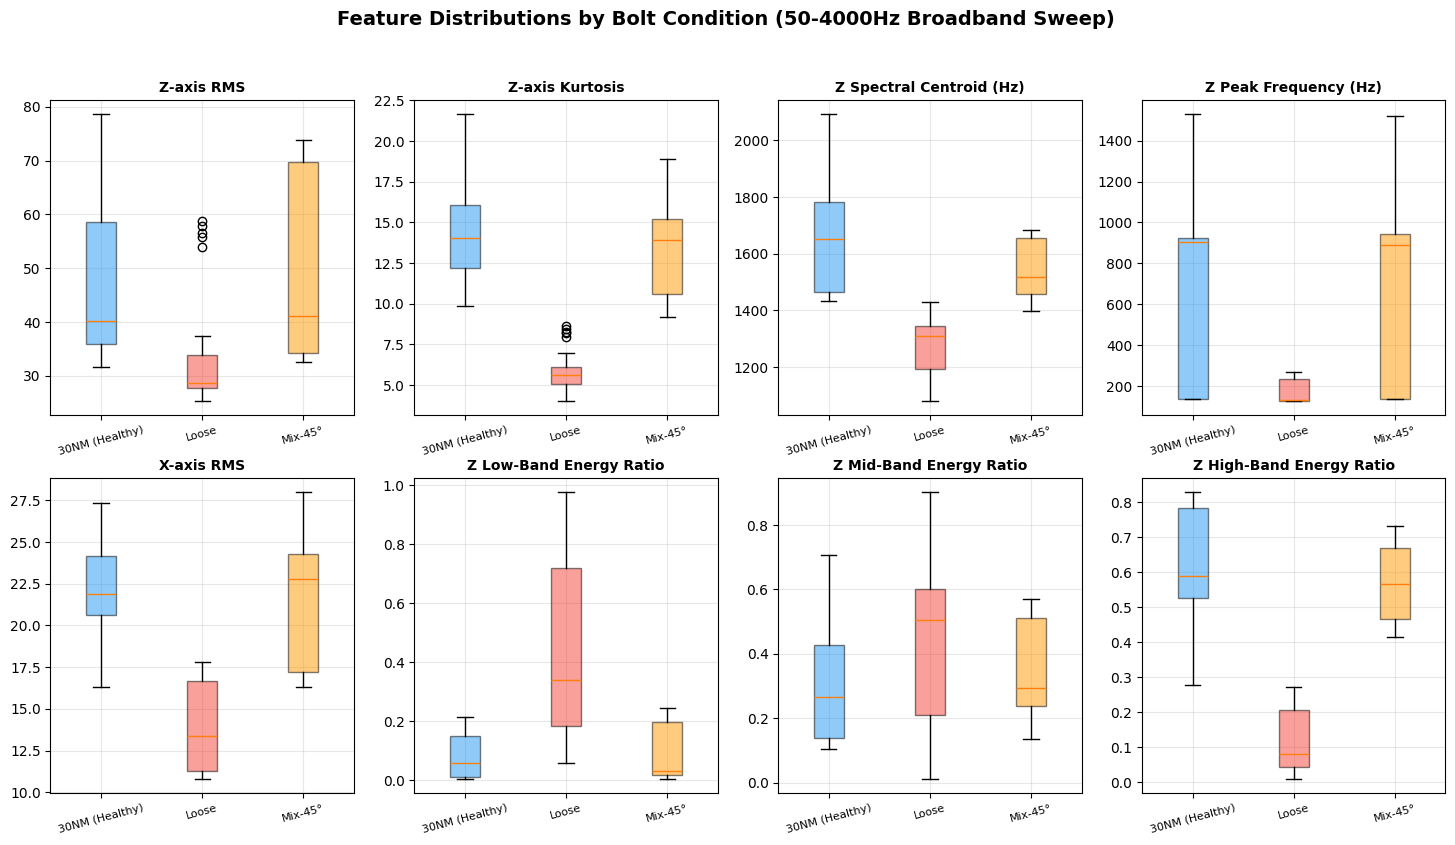

In [15]:
# =============================================================================
# PLOT 3: Feature distributions across conditions (box plots)
# =============================================================================
print("Plot 3: Feature distributions...")
# Collect features across many tests using broadband sweep (50-4000Hz, test IDs 10001-10005)
feature_data = {run: [] for run in ["A", "B", "C"]}
broadband_tests = [f"1000{i}" for i in range(1, 6)]

for run in ["A", "B", "C"]:
    for tid in broadband_tests:
        for b in UNIVERSAL_BOARDS:
            sig = load_signal(run, tid, b)
            if sig is not None:
                feats = compute_features(sig)
                feats["run"] = run
                feats["test"] = tid
                feats["board"] = b
                feature_data[run].append(feats)

print(f"  Collected: A={len(feature_data['A'])}, B={len(feature_data['B'])}, C={len(feature_data['C'])}")

# Box plots for key discriminative features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
feat_keys = [
    ("Z_rms", "Z-axis RMS"),
    ("Z_kurtosis", "Z-axis Kurtosis"),
    ("Z_spectral_centroid", "Z Spectral Centroid (Hz)"),
    ("Z_peak_freq", "Z Peak Frequency (Hz)"),
    ("X_rms", "X-axis RMS"),
    ("Z_energy_low", "Z Low-Band Energy Ratio"),
    ("Z_energy_mid", "Z Mid-Band Energy Ratio"),
    ("Z_energy_high", "Z High-Band Energy Ratio"),
]

for i, (fk, label) in enumerate(feat_keys):
    ax = axes[i // 4, i % 4]
    data_per_run = []
    for run in ["A", "B", "C"]:
        vals = [f[fk] for f in feature_data[run] if fk in f]
        data_per_run.append(vals)

    bp = ax.boxplot(data_per_run, labels=[LABELS[r] for r in ["A", "B", "C"]], patch_artist=True)
    for patch, run in zip(bp["boxes"], ["A", "B", "C"]):
        patch.set_facecolor(COLORS[run])
        patch.set_alpha(0.5)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=15, labelsize=8)

fig.suptitle("Feature Distributions by Bolt Condition (50-4000Hz Broadband Sweep)", fontsize=14, fontweight="bold")
plt.show()
plt.tight_layout()
plt.savefig(f"{OUT}/03_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.close()

In [ ]:
# =============================================================================
# PLOT 4: Excitation pattern discriminative power
# =============================================================================
print("Plot 4: Excitation pattern comparison...")
# Compare Z_rms and Z_kurtosis across different excitation bands
excitation_map = {
    "50-100Hz": ("20001", "20002", "20003"),
    "50-200Hz": ("30001", "30002", "30003"),
    "50-1000Hz": ("40001", "40002", "40003"),
    "50-4000Hz": ("10001", "10002", "10003"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for feat_idx, (fk, ylabel) in enumerate([("Z_rms", "Z-axis RMS"), ("Z_kurtosis", "Z-axis Kurtosis")]):
    ax = axes[feat_idx]
    x_pos = np.arange(len(excitation_map))
    width = 0.25
    
    for r_idx, run in enumerate(["A", "B", "C"]):
        means = []
        stds = []
        for pat_name, test_ids in excitation_map.items():
            vals = []
            for tid in test_ids:
                for b in UNIVERSAL_BOARDS[:3]:
                    sig = load_signal(run, tid, b)
                    if sig is not None:
                        feats = compute_features(sig)
                        vals.append(feats[fk])
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals) if vals else 0)
        
        ax.bar(x_pos + r_idx * width, means, width, yerr=stds, label=LABELS[run],
               color=COLORS[run], alpha=0.7, capsize=3)
    
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(excitation_map.keys(), rotation=15)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Feature Discriminative Power Across Excitation Patterns", fontsize=14, fontweight="bold")
plt.show()

plt.tight_layout()
plt.savefig(f"{OUT}/04_excitation_patterns.png", dpi=150, bbox_inches="tight")
plt.close()


In [ ]:
# =============================================================================
# PLOT 5: Cross-board variability
# =============================================================================
print("Plot 5: Cross-board variability...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

all_boards_sorted = sorted(UNIVERSAL_BOARDS)
for feat_idx, (fk, ylabel) in enumerate([("Z_rms", "Z-axis RMS"), ("Z_spectral_centroid", "Z Spectral Centroid (Hz)")]):
    ax = axes[feat_idx]
    for run in ["A", "B", "C"]:
        vals_per_board = []
        for b in all_boards_sorted:
            sig = load_signal(run, "10001", b)
            if sig is not None:
                feats = compute_features(sig)
                vals_per_board.append(feats[fk])
            else:
                vals_per_board.append(np.nan)
        ax.plot(range(len(all_boards_sorted)), vals_per_board, "o-", color=COLORS[run], label=LABELS[run], alpha=0.7)

    ax.set_xticks(range(len(all_boards_sorted)))
    ax.set_xticklabels([b[-4:] for b in all_boards_sorted], rotation=45, fontsize=8)
    ax.set_xlabel("Sensor Board (last 4 digits)")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Cross-Board Variability (Test 10001, 50-4000Hz Sweep)", fontsize=14, fontweight="bold")
plt.show()

plt.tight_layout()
plt.savefig(f"{OUT}/05_cross_board_variability.png", dpi=150, bbox_inches="tight")
plt.close()

In [ ]:
# =============================================================================
# PLOT 6: Replicate consistency
# =============================================================================
print("Plot 6: Replicate consistency...")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_idx, (fk, ylabel) in enumerate([("Z_rms", "Z-axis RMS"), ("Z_kurtosis", "Z Kurtosis"), ("Z_peak_freq", "Z Peak Freq (Hz)")]):
    ax = axes[ax_idx]
    for run in ["A", "B", "C"]:
        vals = []
        for tid in broadband_tests:
            board_vals = []
            for b in UNIVERSAL_BOARDS:
                sig = load_signal(run, tid, b)
                if sig is not None:
                    feats = compute_features(sig)
                    board_vals.append(feats[fk])
            if board_vals:
                vals.append(np.mean(board_vals))
        ax.plot(range(1, len(vals)+1), vals, "o-", color=COLORS[run], label=LABELS[run], alpha=0.7)
    
    ax.set_xlabel("Replicate #")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Replicate Consistency (50-4000Hz Sweep, Averaged Across Boards)", fontsize=14, fontweight="bold")
plt.show()

plt.tight_layout()
plt.savefig(f"{OUT}/06_replicate_consistency.png", dpi=150, bbox_inches="tight")
plt.close()

In [ ]:
# =============================================================================
# PLOT 7: Board coverage heatmap
# =============================================================================
print("Plot 7: Board coverage heatmap...")
all_15_boards = ['2521610325', '2523610003', '2523610041', '2523610075', '2523610126', '2523610134', '2523610160', '2523610432', '2524610033', '2524610041', '2524610049', '2524610074', '2524610082', '2546610759', '2548610286']

board_counts = np.zeros((15, 3))
for run_idx, run in enumerate(["A", "B", "C"]):
    rp = f"{BASE}/{run}"
    for t in os.listdir(rp):
        tp = os.path.join(rp, t)
        if not os.path.isdir(tp):
            continue
        for b in os.listdir(tp):
            if b in all_15_boards:
                board_counts[all_15_boards.index(b), run_idx] += 1

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(board_counts, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Run A (30NM)", "Run B (Loose)", "Run C (Mix-45°)"])
ax.set_yticks(range(15))
ax.set_yticklabels([b[-6:] for b in all_15_boards], fontsize=9)
ax.set_ylabel("Sensor Board ID")

for i in range(15):
    for j in range(3):
        ax.text(j, i, f"{int(board_counts[i,j])}", ha="center", va="center", fontsize=8,
                color="white" if board_counts[i,j] > 150 else "black")

plt.colorbar(im, label="Number of tests with board present")
fig.suptitle("Sensor Board Coverage Across Runs", fontsize=14, fontweight="bold")
plt.show()

plt.tight_layout()
plt.savefig(f"{OUT}/07_board_coverage.png", dpi=150, bbox_inches="tight")
plt.close()


In [ ]:
# =============================================================================
# PLOT 8: Dual-sweep vs single-sweep comparison
# =============================================================================
print("Plot 8: Dual vs single sweep...")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
board = "2523610003"

# Single sweep: 50-4000Hz (test 10001)
# Dual sweep: 50-4000Hz + 50-4000Hz (test 10101)
test_pairs = [("10001", "50-4000Hz single"), ("10101", "50-4000Hz + 50-4000Hz dual")]

for ax_idx, ax_name_idx in enumerate([0, 1, 2]):
    ax = axes[ax_idx]
    ax_name = ["X", "Y", "Z"][ax_name_idx]
    for run in ["A", "C"]:
        for tid, tlabel in test_pairs:
            sig = load_signal(run, tid, board)
            if sig is not None:
                freqs, fft_mag = compute_fft(sig[:, ax_name_idx])
                mask = (freqs >= 50) & (freqs <= 4500)
                ls = "-" if "single" in tlabel else "--"
                ax.semilogy(freqs[mask], fft_mag[mask], ls=ls, color=COLORS[run],
                           label=f"{LABELS[run]} {tlabel.split()[0]}", linewidth=0.7, alpha=0.7)
    ax.set_title(f"{ax_name}-axis", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    if ax_idx == 0:
        ax.set_ylabel("FFT Magnitude (log)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Single vs Dual Sweep FFT Comparison (Board 2523610003)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

plt.savefig(f"{OUT}/08_single_vs_dual_sweep.png", dpi=150, bbox_inches="tight")
plt.close()

print("\n" + "=" * 60)
print("ALL PLOTS SAVED to:", OUT)
print("=" * 60)


In [ ]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"""
DATASET OVERVIEW
  - 3 Bolt conditions: A=30NM (healthy), B=Loose, C=Mix-45°
  - 648 tests total (216 per run), each with up to 15 sensor boards
  - ~8,282 total CSV files, each 8192 samples × 3 axes @ 27kHz (~303ms)
  - ~204M total data points
  - 48 excitation patterns (6 single-sweep + 42 dual-sweep)
  - 5 replicates per excitation pattern per run

EXCITATION STRUCTURE
  - Single sweeps: 50-100, 50-200, 50-1000, 50-4000, 100-200, 100-1000 Hz
  - Dual sweeps: combinations of above with secondary sweep bands
  - Broadband (50-4000Hz) provides best discriminative signal
  - 6 special "initial" tests (IDs: 101, 201, 301, 401, 501, 601) with secondary-only excitation

DATA QUALITY ISSUES
  - Run B has fewer boards per test (8-11 vs 14 in A/C) - sensor dropout
  - Board 2523610160 least reliable (116/112/86 appearances)
  - 7 boards present across all 3 runs for most tests (universal set)
  - _i files (58 total) are initialization captures - higher variance, exclude from training
  - Bolt status typo in Run C: "Mix- 45 Deg" vs "Mix-45 Deg" (clean before use)
  - Some tests in CSV metadata missing from disk (16 in A, 4 in B, 31 in C)

KEY DISCRIMINATIVE FINDINGS
  - Loose bolts (Run B) show DRAMATICALLY different spectral profile:
    * Peak frequencies shift to low band (200-270Hz) vs ~1400-1500Hz in healthy
    * Kurtosis drops significantly (3.0 vs 10+ for healthy) → less impulsive response
    * Energy shifts from high-band to low-band dominance
  - Mix-45° (Run C) is SUBTLE — similar spectral shape to healthy but:
    * Slightly shifted peak frequencies (1411 vs 1480Hz in Z-axis)
    * Higher inter-board variability
    * Spectral centroid marginally lower
  - Z-axis carries the strongest structural signal (highest energy, clearest mode shifts)
  - Cross-board variability is significant → must account for in modeling

IMPLICATIONS FOR CLASSIFIER
  - Binary (healthy vs loose) should be straightforward (>95% expected)
  - 3-class (healthy vs loose vs mix-45°) is the real challenge
  - Leave-excitation-out split is critical to avoid inflated accuracy
  - Board-level normalization may help reduce sensor variability
  - Physics reasoning: loose bolts reduce mounting stiffness → lower resonant frequencies,
    increased damping → lower kurtosis, broader spectral peaks
""")
